# Sustainabilty models

In [41]:
# ----------------------------
# IMPORTS + CONFIG
# ----------------------------

import re
from pathlib import Path

import bertopic
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from bs4 import BeautifulSoup
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import plot_tree

# ============================================================
# SETTINGS
# ============================================================

pd.set_option(
    'display.float_format',
    '{:.2f}'.format
)


PROJECT_ROOT = Path.cwd().parent

CONFIG = {
    "features_dir": PROJECT_ROOT / "01_data" / "03_features",
    "input_file": "llm_sustainability_strict_v1-2-0_dataframe.csv",
    "output_file": "llm_sustainability_strict_v1-3-0_dataframe.csv",
    "embeddings_file": "llm_sustainability_strict_v1-1-0_embeddings.npy",
    "random_state": 42,
}

INPUT_PATH = CONFIG["features_dir"] / CONFIG["input_file"]
OUTPUT_PATH = CONFIG["features_dir"] / CONFIG["output_file"]
EMBEDDINGS_PATH = CONFIG["features_dir"] / CONFIG["embeddings_file"]

print("INPUT_PATH:", INPUT_PATH)
print("OUTPUT_PATH:", OUTPUT_PATH)
print("EMBEDDINGS_PATH:", EMBEDDINGS_PATH)

INPUT_PATH: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-2-0_dataframe.csv
OUTPUT_PATH: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-3-0_dataframe.csv
EMBEDDINGS_PATH: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-1-0_embeddings.npy


In [42]:
# ----------------------------
# IO HELPERS
# ----------------------------

def load_csv(INPUT_PATH):
    with Path(INPUT_PATH).open("r", encoding="utf-8") as file:
        return pd.read_csv(file)

def load_emb(EMBEDDINGS_PATH):
    with Path(EMBEDDINGS_PATH).open("rb") as file:
        return np.load(file)

def save_csv(df, OUTPUT_PATH):
    path = Path(OUTPUT_PATH)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


In [43]:
# ----------------------------
# LOAD DATA
# ----------------------------

embeddings = load_emb(EMBEDDINGS_PATH)

df = load_csv(INPUT_PATH)

print("Input path:", INPUT_PATH)
print("Exists:", INPUT_PATH.exists())
print("Shape:", df.shape)
print("Embeddings shape:", embeddings.shape)

df.head()

Input path: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-2-0_dataframe.csv
Exists: True
Shape: (46429, 36)
Embeddings shape: (46429, 384)


,conversation_id,first_prompt,first_response,first_prompt_tokens,first_response_tokens,total_turns,interaction_rounds,total_user_prompts,followup_prompts,needs_follow_up,...,topic_label,topic_cat,embedding_novelty,target_cost,log_target_cost,target_no_refusal,target_no_capability,target_needs_clarification,log_first_prompt_tokens,log_question_count
0,QWJhYvA,Summarize the main ideas of Jeff Walker's Prod...,<div><p>Here are the main ideas of Jeff Walker...,34,304,12,6.00,6,5,1,...,0_chatgpt_write_use_like_want,general,0.55,304,5.72,1,1,0,3.56,0.00
1,i6IyJda,How to tell if a customer segment is well segm...,"<div class=""markdown prose w-full break-words ...",17,113,2,1.00,1,0,0,...,-1_like_data_use_write_make,noise,0.78,113,4.74,1,1,0,2.89,0.69
2,A5AbcES,"In Java, I want to replace string like ""This i...","<div class=""markdown prose w-full break-words ...",62,1468,2,1.00,1,0,0,...,-1_like_data_use_write_make,noise,0.96,1468,7.29,1,1,0,4.14,0.69
3,hRPPgZT,Metaphorical language is also used to describe...,<div><p>Metaphorical language has been summone...,90,132,22,11.00,11,10,1,...,-1_like_data_use_write_make,noise,0.73,132,4.89,1,1,0,4.51,0.00
4,KXxu9my,The following is the job of the hosting servic...,"<div class=""markdown prose w-full break-words ...",507,1014,10,5.00,5,4,1,...,-1_like_data_use_write_make,noise,0.59,1014,6.92,1,1,0,6.23,0.00


In [44]:
df.columns

Index(['conversation_id', 'first_prompt', 'first_response',
       'first_prompt_tokens', 'first_response_tokens', 'total_turns',
       'interaction_rounds', 'total_user_prompts', 'followup_prompts',
       'needs_follow_up', 'total_user_tokens', 'total_assistant_tokens',
       'total_tokens', 'log_total_tokens', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
       'question_count', 'prompt_style', 'task_type',
       'orthographic_error_rate', 'is_valid_prompt', 'clean_response',
       'clean_prompt', 'topic', 'topic_prob', 'topic_label', 'topic_cat',
       'embedding_novelty', 'target_cost', 'log_target_cost',
       'target_no_refusal', 'target_no_capability',
       'target_needs_clarification', 'log_first_prompt_tokens',
       'log_question_count'],
      dtype='str')

In [45]:
df.dtypes

conversation_id                          str
first_prompt                             str
first_response                           str
first_prompt_tokens                    int64
first_response_tokens                  int64
total_turns                            int64
interaction_rounds                   float64
total_user_prompts                     int64
followup_prompts                       int64
needs_follow_up                        int64
total_user_tokens                      int64
total_assistant_tokens                 int64
total_tokens                           int64
log_total_tokens                     float64
has_role_instruction                   int64
has_audience_or_level_instruction      int64
has_format_instruction                 int64
question_count                         int64
prompt_style                             str
task_type                                str
orthographic_error_rate              float64
is_valid_prompt                        int64
clean_resp

In [46]:
# dtypes

df["prompt_style"]=df["prompt_style"].astype("category")
df["task_type"]=df["task_type"].astype("category")
df["topic_label"]=df["topic_label"].astype("category")
df["topic_cat"]=df["topic_cat"].astype("category")


df["target_no_refusal"]=df["target_no_refusal"].astype("int")
df["target_no_capability"]=df["target_no_capability"].astype("int")
df["target_needs_clarification"]=df["target_needs_clarification"].astype("int")

#df.dtypes

In [47]:
# ----------------------------
# FEATURE / TARGET SPLIT
# ----------------------------

FEATURE_COLUMNS = [
    "conversation_id",
    "first_prompt",
    "first_response",
    "first_prompt_tokens",
    "log_first_prompt_tokens",
    "first_response_tokens",
    "total_turns",
    "interaction_rounds",
    "total_user_prompts",
    "needs_follow_up",
    "total_user_tokens",
    "total_assistant_tokens",
    "total_tokens",
    "log_total_tokens",
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
    "question_count",
    "log_question_count",
    "prompt_style",
    "task_type",
    "orthographic_error_rate",
    "is_valid_prompt",
    "topic",
    "topic_cat",
    "topic_prob",
    "topic_label",
    "embedding_novelty",
]

TARGET_COLUMNS = [
    "conversation_id",
    "target_cost",
    "log_target_cost",
    "target_no_refusal",
    "target_no_capability",
    "target_needs_clarification"
]

df_features = df[FEATURE_COLUMNS].copy()
df_target = df[TARGET_COLUMNS].copy()

In [48]:
# ----------------------------
# FEATURE GROUPS
# ----------------------------

central_features = [
    "first_prompt_tokens",
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
    "question_count",
    "prompt_style",
    "task_type",
    "orthographic_error_rate",
    "topic_prob",
    "topic_cat", 
    "embedding_novelty",
]

high_cardinality_features = [
    "topic_label",
]

targets = [
    "target_cost",
    "log_target_cost",
    "target_no_refusal",
    "target_no_capability",
    "target_needs_clarification",
]    

numeric_features = [
    "first_prompt_tokens",
    "log_first_prompt_tokens",
    "question_count",
    "log_question_count",
    "orthographic_error_rate",
    "topic_prob", 
    "embedding_novelty",
]

binary_features = [
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
]

categorical_features = [
    "prompt_style",
    "task_type",
    "topic_cat",
]

id_text_columns = [
    "conversation_id",
    "first_prompt",
    "first_response",
]

print("Central features:", central_features)
print("High-cardinality features:", high_cardinality_features)
print("Target features:", targets)

Central features: ['first_prompt_tokens', 'has_role_instruction', 'has_audience_or_level_instruction', 'has_format_instruction', 'question_count', 'prompt_style', 'task_type', 'orthographic_error_rate', 'topic_prob', 'topic_cat', 'embedding_novelty']
High-cardinality features: ['topic_label']
Target features: ['target_cost', 'log_target_cost', 'target_no_refusal', 'target_no_capability', 'target_needs_clarification']


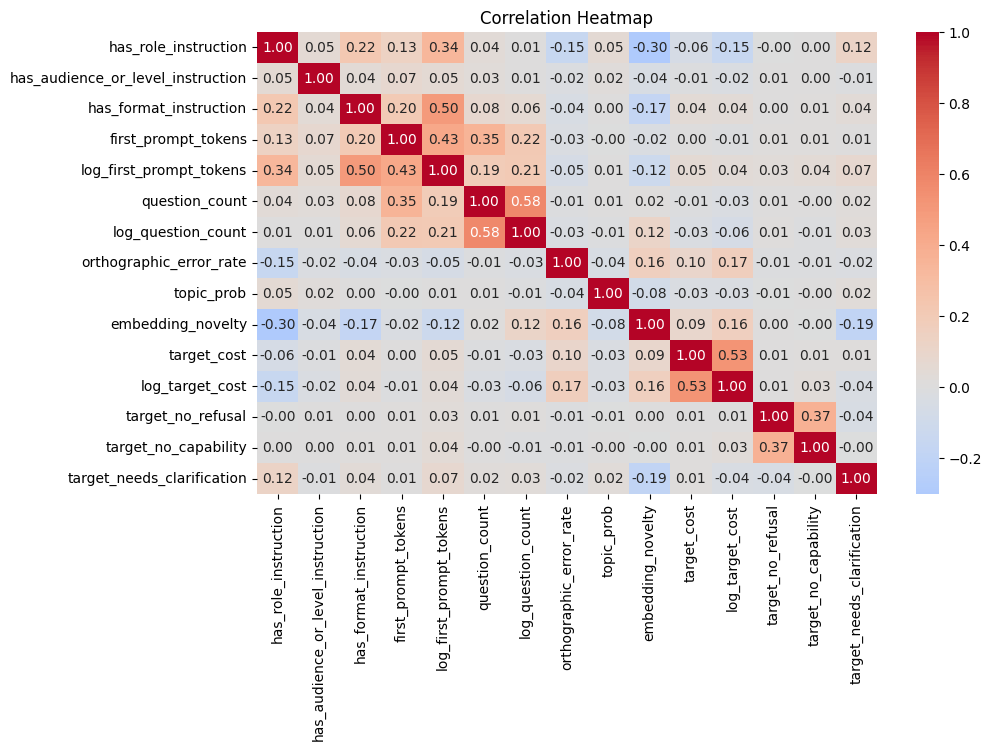

In [49]:
# ----------------------------
# CORRELATIONS
# ----------------------------

features_for_corr = binary_features + numeric_features + targets

corr = df[features_for_corr].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

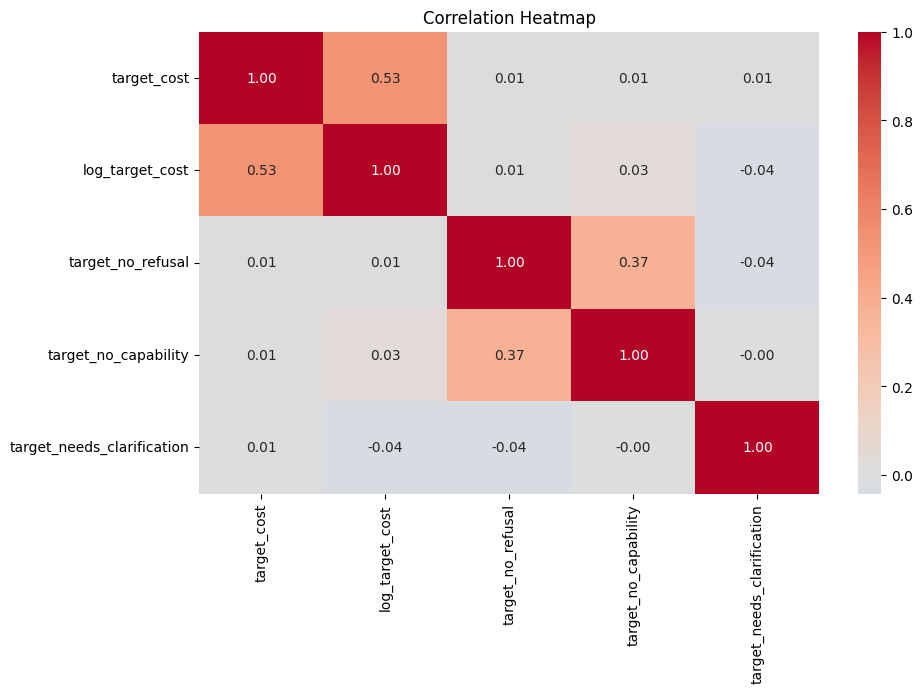

In [50]:
features_for_corr = targets

corr = df[features_for_corr].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# Features selection

In [51]:
# features selection v01 - Structural prompt features

FEATURES_SELECTED_v01 = {
    "cat": [],
    "num": [
        "log_first_prompt_tokens",
        "log_question_count",
        "orthographic_error_rate",
    ],
    "bin": [
        "has_role_instruction",
        "has_audience_or_level_instruction",
        "has_format_instruction",
    ],
    "emb": []
}


# features selection v02 -  Structural + engineered semantic features
  
FEATURES_SELECTED_v02 = {
    "cat": [
        "task_type",
        "topic_cat",
    ],
    "num": [
        "log_first_prompt_tokens",
        "log_question_count",
        "embedding_novelty",
        "topic_prob",
        "orthographic_error_rate",
    ],
    "bin": [
        "has_role_instruction",
        "has_audience_or_level_instruction",
        "has_format_instruction",
    ],
    "emb": []
}


# features selection v03 - Structural + engineered semantic features + dense embeddings

embedding_cols = [
    f"embedding_{i}" for i in range(x_train_emb.shape[1])
]

df_emb_train = pd.DataFrame(
    x_train_emb,
    columns=embedding_cols,
    index=x_train_df.index
)

df_emb_test = pd.DataFrame(
    x_test_emb,
    columns=embedding_cols,
    index=x_test_df.index
)

x_train_full = pd.concat(
    [x_train_df, df_emb_train],
    axis=1
)

x_test_full = pd.concat(
    [x_test_df, df_emb_test],
    axis=1
)

FEATURES_SELECTED_v03 = {
    "cat": [
        "task_type",
        "topic_cat",
    ],
    "num": [
        "log_first_prompt_tokens",
        "log_question_count",
        "embedding_novelty",
        "topic_prob",
        "orthographic_error_rate",
    ],
    "bin": [
        "has_role_instruction",
        "has_audience_or_level_instruction",
        "has_format_instruction",
    ],
    "emb": embedding_cols
}

FEATURES_SELECTIONS = {
    "v01": FEATURES_SELECTED_v01,
    "v02": FEATURES_SELECTED_v02,
    "v03": FEATURES_SELECTED_v03,
}

# drop: question_count, total_turns, interaction_rounds, total_user_tokens, total_assistant_tokens, total_tokens, log_total_tokens

# Train test split for "target_no_refusal"

In [52]:
x_train_df, x_test_df, x_train_emb, x_test_emb = train_test_split(
    df,
    embeddings,
    test_size=0.2,
    random_state=42,
    stratify=df["target_no_refusal"]
)

# Logistic regression modell "target_no_refusal"

In [53]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def original_feature_name(feature):

    # numeric features
    for col in features["num"]:
        if feature == f"num__{col}":
            return col

    # binary features
    for col in features["bin"]:
        if feature == f"bin__{col}":
            return col

    # categorical features (OHE)
    for col in features["cat"]:
        if feature.startswith(f"cat__{col}_"):
            return col

       # embeddings
    for col in features.get("emb", []):
        if feature.startswith(f"emb__{col}"):
            return "embeddings"

    return feature

for version, features in FEATURES_SELECTIONS.items():

    features_cols = (
        features.get("cat", [])
        + features.get("num", [])
        + features.get("bin", [])
        + features.get("emb", [])
    )
    
    # preprocess
    transformers = []

    if "num" in features:
        transformers.append(
            ("num", StandardScaler(), features["num"])
        )

    if "emb" in features:
        transformers.append(
            ("emb", StandardScaler(), features["emb"])
        )

    if "bin" in features:
        transformers.append(
            ("bin", "passthrough", features["bin"])
        )

    if "cat" in features:
        transformers.append(
            ("cat", OneHotEncoder(handle_unknown="ignore"), features["cat"])
        )

    preprocess = ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )  


    # model
    model_reg = LogisticRegression(max_iter=2000, class_weight="balanced") 

    # pipeline
    pipeline = Pipeline([
        ("preprocess", preprocess), 
        ("model", model_reg)
    ])

    results = cross_validate(
        pipeline,
        x_train_full[features_cols],
        x_train_df["target_no_refusal"],
        cv=cv,
        scoring=["roc_auc", "f1", "precision", "recall"]
    )

    print("##########")
    print(version)
    print(
        "ROC AUC:",
        results["test_roc_auc"].mean()
    )
    print(
        "F1:",
        results["test_f1"].mean()
    )

    print(
        "Precision:",
        results["test_precision"].mean()
    )

    print(
        "Recall:",
        results["test_recall"].mean()
    )

    # fit model

    if "emb" in features:
        x_train = x_train_full
        x_test = x_test_full
    else:
        x_train = x_train_df
        x_test = x_test_df

    pipeline.fit(
        x_train_full[features_cols],
        x_train_df["target_no_refusal"]
        )

    # predict test
    target_no_refusal_test_pred = pipeline.predict(
        x_test_full[features_cols]
    )

    target_no_refusal_test_proba = pipeline.predict_proba(
        x_test_full[features_cols]
    )[:, 1]

    # names of features

    model = pipeline.named_steps["model"]
    preprocess = pipeline.named_steps["preprocess"]

    feature_names = preprocess.get_feature_names_out()

    coefficients = model.coef_[0]

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients
    })

    coef_df = coef_df.sort_values("coefficient", ascending=False)


    # SHAP    

    features_train_transformed = preprocess.transform(x_train_full[features_cols])
    features_test_transformed = preprocess.transform(x_test_full[features_cols])

    explainer = shap.LinearExplainer(
    model,
    features_train_transformed
    )

    shap_values = explainer(features_test_transformed)


    fi_shap = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(shap_values.values).mean(axis=0)
    }).sort_values("importance", ascending=False)


    fi_shap["original_feature"] = (
        fi_shap["feature"]
        .apply(original_feature_name)
    )

    grouped_importance = (
        fi_shap.groupby("original_feature", as_index=False)["importance"]
               .mean()
            .sort_values("importance", ascending=False)
    )
 

    # metrics
    print("##########")
    print(version)
    print("##########")
    print("ROC AUC:", roc_auc_score(x_test_df["target_no_refusal"], target_no_refusal_test_proba))
    print("f1_score:", f1_score(x_test_df["target_no_refusal"], target_no_refusal_test_pred))
    print("Precision:", precision_score(x_test_df["target_no_refusal"], target_no_refusal_test_pred))
    print("Recall:", recall_score(x_test_df["target_no_refusal"], target_no_refusal_test_pred))
    print(coef_df.head(40))
    print(grouped_importance)

##########
v01
ROC AUC: 0.4920438625635987
F1: 0.6450924671658834
Precision: 0.9767340635215408
Recall: 0.485153101042097
##########
v01
##########
ROC AUC: 0.48118139939977755
f1_score: 0.6927612417418484
Precision: 0.9750049990002
Recall: 0.5372410753635963
                                  feature  coefficient
4  bin__has_audience_or_level_instruction         0.50
2            num__orthographic_error_rate         0.03
0            num__log_first_prompt_tokens         0.01
5             bin__has_format_instruction         0.00
1                 num__log_question_count        -0.00
3               bin__has_role_instruction        -0.10
                    original_feature  importance
2               has_role_instruction        0.03
5            orthographic_error_rate        0.02
3            log_first_prompt_tokens        0.01
0  has_audience_or_level_instruction        0.00
4                 log_question_count        0.00
1             has_format_instruction        0.00
##########
v

# Analysis Summary

## Objective
Predict whether an LLM response contains a refusal pattern based on prompt characteristics.

## Defined target
```python
refusal_pattern = (
    r"(i\s+cannot"
    r"|i\s+can't"
    r"|i\s+do\s+not\s+have\s+access"
    r"|i\s+don't\s+have\s+access"
    r"|i['’]?m\s+sorry.*?(cannot|can't)"
    r"|as\s+an\s+ai\s+language\s+model.*?(cannot|can't))"
)
df["target_no_refusal"] = (
    ~df["first_response"].fillna("").str.contains(refusal_pattern, regex=True)
).astype(int)
```


## Approach
Three feature sets were evaluated:

- v01: structural prompt features
- v02: structural + semantic metadata
- v03: structural + semantic features + embeddings

Models were evaluated using stratified 5-fold cross-validation and a final holdout test set.

## Key Result

Adding embeddings substantially improved prediction performance:

| Model | ROC AUC | F1 | Top3 most important features [SHAP]|
|---|---:|---:|---:|
| v01 | 0.57 | 0.65 | log_first_prompt_tokens, has_role_instruction, has_format_instruction |
| v02 | 0.60 | 0.67 | log_first_prompt_tokens, topic_cat, has_format_instruction |
| v03 | 0.73 | 0.84 | log_first_prompt_tokens, has_format_instruction, embeddings|


Simple structural prompt features have only limited predictive power for the occurrence of refusals. Adding task and topic categories slightly improves model performance. Only through the integration of semantic embeddings does the prediction quality increase significantly (ROC-AUC ≈ 0.74). This suggests that refusals depend primarily on the semantic content of a prompt and less on superficial prompt characteristics.

# Train test split for "target_no_capability"

In [54]:
x_train_df, x_test_df, x_train_emb, x_test_emb = train_test_split( df, embeddings, test_size=0.2, random_state=42, stratify=df["target_no_capability"] )

# Logistic regression modell "target_no_capability"

In [55]:
for version, features in FEATURES_SELECTIONS.items():

    features_cols = (
        features.get("cat", [])
        + features.get("num", [])
        + features.get("bin", [])
        + features.get("emb", [])
    )
    
    # preprocess
    transformers = []

    if "num" in features:
        transformers.append(
            ("num", StandardScaler(), features["num"])
        )

    if "emb" in features:
        transformers.append(
            ("emb", StandardScaler(), features["emb"])
        )

    if "bin" in features:
        transformers.append(
            ("bin", "passthrough", features["bin"])
        )

    if "cat" in features:
        transformers.append(
            ("cat", OneHotEncoder(handle_unknown="ignore"), features["cat"])
        )

    preprocess = ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )  


    # model
    model_reg = LogisticRegression(max_iter=2000, class_weight="balanced") 

    # pipeline
    pipeline = Pipeline([
        ("preprocess", preprocess), 
        ("model", model_reg)
    ])

    results = cross_validate(
        pipeline,
        x_train_full[features_cols],
        x_train_df["target_no_capability"],
        cv=cv,
        scoring=["roc_auc", "f1", "precision", "recall"]
    )

    print("##########")
    print(version)
    print(
        "ROC AUC:",
        results["test_roc_auc"].mean()
    )
    print(
        "F1:",
        results["test_f1"].mean()
    )

    print(
        "Precision:",
        results["test_precision"].mean()
    )

    print(
        "Recall:",
        results["test_recall"].mean()
    )

    # fit model

    if "emb" in features:
        x_train = x_train_full
        x_test = x_test_full
    else:
        x_train = x_train_df
        x_test = x_test_df

    pipeline.fit(
        x_train_full[features_cols],
        x_train_df["target_no_capability"]
        )

    # predict test
    target_no_capability_test_pred = pipeline.predict(
        x_test_full[features_cols]
    )

    target_no_capability_test_proba = pipeline.predict_proba(
        x_test_full[features_cols]
    )[:, 1]

    # names of features

    model = pipeline.named_steps["model"]
    preprocess = pipeline.named_steps["preprocess"]

    feature_names = preprocess.get_feature_names_out()

    coefficients = model.coef_[0]

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients
    })

    coef_df = coef_df.sort_values("coefficient", ascending=False)


    # SHAP    

    features_train_transformed = preprocess.transform(x_train_full[features_cols])
    features_test_transformed = preprocess.transform(x_test_full[features_cols])

    explainer = shap.LinearExplainer(
    model,
    features_train_transformed
    )

    shap_values = explainer(features_test_transformed)


    fi_shap = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(shap_values.values).mean(axis=0)
    }).sort_values("importance", ascending=False)


    fi_shap["original_feature"] = (
        fi_shap["feature"]
        .apply(original_feature_name)
    )

    grouped_importance = (
        fi_shap.groupby("original_feature", as_index=False)["importance"]
               .mean()
            .sort_values("importance", ascending=False)
    )
 

    # metrics
    print("##########")
    print(version)
    print("##########")
    print("ROC AUC:", roc_auc_score(x_test_df["target_no_capability"], target_no_capability_test_proba))
    print("f1_score:", f1_score(x_test_df["target_no_capability"], target_no_capability_test_pred))
    print("Precision:", precision_score(x_test_df["target_no_capability"], target_no_capability_test_pred))
    print("Recall:", recall_score(x_test_df["target_no_capability"], target_no_capability_test_pred))
    print(coef_df.head(40))
    print(grouped_importance)

##########
v01
ROC AUC: 0.4984723603093739
F1: 0.694737085368442
Precision: 0.989593062959176
Recall: 0.5396285383214945
##########
v01
##########
ROC AUC: 0.5189216600305385
f1_score: 0.6391631059378223
Precision: 0.9892816419612315
Recall: 0.4720861900097943
                                  feature  coefficient
4  bin__has_audience_or_level_instruction         0.83
2            num__orthographic_error_rate         0.06
0            num__log_first_prompt_tokens         0.04
1                 num__log_question_count        -0.02
5             bin__has_format_instruction        -0.09
3               bin__has_role_instruction        -0.12
                    original_feature  importance
5            orthographic_error_rate        0.05
1             has_format_instruction        0.04
3            log_first_prompt_tokens        0.03
2               has_role_instruction        0.03
4                 log_question_count        0.02
0  has_audience_or_level_instruction        0.00
##########


# Analysis Summary

## Objective
Predict whether a response from a large language model (LLM) contains a response pattern that expresses rejection due to a lack of capability.

## Defined target
```python
capability_pattern = (
    r"(i\s+(do\s+not|don't)\s+have\s+access"
    r"|i\s+cannot\s+access"
    r"|i\s+cannot\s+browse"
    r"|i\s+cannot\s+interact"
    r"|i\s+cannot\s+connect"
    r"|i\s+cannot\s+directly\s+"
    r"|i\s+do\s+not\s+have\s+the\s+ability\s+to"
    r"|i\s+don't\s+have\s+the\s+ability\s+to"
    r"|i\s+am\s+unable\s+to\s+)"
)

df["target_no_capability"] = (
    ~df["clean_response"]
    .fillna("")
    .str.contains(
        capability_pattern,
        regex=True,
        case=False
    )
).astype(int)

```


## Approach
Three feature sets were evaluated:

- v01: structural prompt features
- v02: structural + semantic metadata
- v03: structural + semantic features + embeddings

Models were evaluated using stratified 5-fold cross-validation and a final holdout test set.

## Key Result

Adding embeddings substantially improved prediction performance:

| Model | ROC AUC | F1 | Top3 most important features [SHAP]|
|---|---:|---:|---:|
| v01 | 0.56 | 0.64 | log_first_prompt_tokens, has_role_instruction, has_format_instruction |
| v02 | 0.59 | 0.65 | log_first_prompt_tokens, topic_cat, has_format_instruction |
| v03 | 0.72 | 0.88 | log_first_prompt_tokens, embeddings, has_format_instruction |


Simple structural prompt features have only limited predictive power for the occurrence of refusals. Adding task and topic categories slightly improves model performance. Only through the integration of semantic embeddings does the prediction quality increase significantly (ROC-AUC ≈ 0.74). This suggests that refusals depend primarily on the semantic content of a prompt and less on superficial prompt characteristics.


## Comparison models for "target_no_refusal" and "target_no_capability"

The models for “No Refusal” and “No Capability” show a high degree of agreement regarding the most important predictors. Across all model variants, prompt length, topic categories (technical, domain), task types, and semantic embeddings are among the strongest influencing factors. The consistent ranking of these features across different target variables supports the robustness and plausibility of the identified relationships. At the same time, it points out that different forms of rejection or restriction responses are, in part, determined by similar characteristics of the prompts.

# Train test split for "log_target_cost"

In [56]:
df["target_bin"] = pd.qcut(
    df["log_target_cost"],
    q=10,
    labels=False
)

x_train_df, x_test_df, x_train_emb, x_test_emb = train_test_split(
    df,
    embeddings,
    test_size=0.2,
    random_state=42,
    stratify=df["target_bin"]
)

x_train_df = x_train_df.drop(columns=["target_bin"])
x_test_df = x_test_df.drop(columns=["target_bin"])

# Linear regression modell "log_target_cost"

In [57]:
best_pipelines = {}
best_alphas = {}
best_scores = {}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
alphas = [0.1, 1, 10, 100]

for version, features in FEATURES_SELECTIONS.items():
    features_cols = (
        features.get("cat", [])
        + features.get("num", [])
        + features.get("bin", [])
        + features.get("emb", [])
    )

    transformers = []
    if features.get("num", []):
        transformers.append(("num", StandardScaler(), features["num"]))
    if features.get("emb", []):
        transformers.append(("emb", StandardScaler(), features["emb"]))
    if features.get("bin", []):
        transformers.append(("bin", "passthrough", features["bin"]))
    if features.get("cat", []):
        transformers.append(("cat", OneHotEncoder(handle_unknown="ignore"), features["cat"]))


    # preprocess
    
    preprocess = ColumnTransformer(transformers=transformers)

    best_r2 = -np.inf
    best_alpha = None
    best_pipeline = None

    for alpha in alphas:
        pipeline = Pipeline([
            ("preprocess", preprocess),
            ("model", Ridge(alpha=alpha))
        ])

        results = cross_validate(
            pipeline,
            x_train_full[features_cols],
            x_train_df["log_target_cost"],
            cv=cv,
            scoring=["r2", "neg_mean_absolute_error"]
        )

        mean_r2 = results["test_r2"].mean()

        #print("##########")
        print(version, "alpha:", alpha, "R²:", mean_r2)

        if mean_r2 > best_r2:
            best_r2 = mean_r2
            best_alpha = alpha
            best_pipeline = pipeline


    # fit model with best alpha
    best_pipeline.fit(x_train_full[features_cols], x_train_df["log_target_cost"])
    best_pipelines[version] = best_pipeline
    best_alphas[version] = best_alpha
    best_scores[version] = best_r2

    print(version)
    print("Best alpha:", best_alpha)
    print("Best CV R²:", best_r2)
    print("################")


    # SHAP 

for version in ["v01", "v02", "v03"]:
    features = FEATURES_SELECTIONS[version]
    features_cols = (
        features.get("cat", [])
        + features.get("num", [])
        + features.get("bin", [])
        + features.get("emb", [])
    )

    pipeline = best_pipelines[version]
    model = pipeline.named_steps["model"]
    preprocess = pipeline.named_steps["preprocess"]
    feature_names = preprocess.get_feature_names_out()

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": model.coef_
    }).sort_values("coefficient", ascending=False)


    features_train_transformed = preprocess.transform(x_train_full[features_cols])
    features_test_transformed = preprocess.transform(x_test_full[features_cols])

    explainer = shap.LinearExplainer(model, features_train_transformed)
    shap_values = explainer(features_test_transformed)

    fi_shap = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(shap_values.values).mean(axis=0)
    }).sort_values("importance", ascending=False)

    fi_shap["original_feature"] = fi_shap["feature"].apply(original_feature_name)
    grouped_importance = (
        fi_shap.groupby("original_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
    )

    print(version)
    display(coef_df.head(40))
    display(grouped_importance)

v01 alpha: 0.1 R²: 0.0596322728938163
v01 alpha: 1 R²: 0.05963256167571287
v01 alpha: 10 R²: 0.05963438641692069
v01 alpha: 100 R²: 0.059597245562363545
v01
Best alpha: 10
Best CV R²: 0.05963438641692069
################
v02 alpha: 0.1 R²: 0.10794267799284554
v02 alpha: 1 R²: 0.10794337616961976
v02 alpha: 10 R²: 0.10794919351997947
v02 alpha: 100 R²: 0.10792904396265086
v02
Best alpha: 10
Best CV R²: 0.10794919351997947
################
v03 alpha: 0.1 R²: 0.31912063289299564
v03 alpha: 1 R²: 0.3191243528324438
v03 alpha: 10 R²: 0.3191572348540818
v03 alpha: 100 R²: 0.3193005858012392
v03
Best alpha: 100
Best CV R²: 0.3193005858012392
################
v01


,feature,coefficient
2,num__orthographic_error_rate,0.16
0,num__log_first_prompt_tokens,0.10
5,bin__has_format_instruction,0.09
1,num__log_question_count,-0.08
4,bin__has_audience_or_level_instruction,-0.21
3,bin__has_role_instruction,-0.48


,original_feature,importance
2,has_role_instruction,0.14
5,orthographic_error_rate,0.12
3,log_first_prompt_tokens,0.09
4,log_question_count,0.06
1,has_format_instruction,0.04
0,has_audience_or_level_instruction,0.00


v02


,feature,coefficient
9,cat__task_type_coding,0.33
20,cat__topic_cat_technical,0.21
15,cat__task_type_translation,0.20
7,bin__has_format_instruction,0.12
2,num__embedding_novelty,0.12
4,num__orthographic_error_rate,0.11
16,cat__task_type_writing_generation,0.10
10,cat__task_type_email_writing,0.04
0,num__log_first_prompt_tokens,0.03
3,num__topic_prob,0.00


,original_feature,importance
7,task_type,0.27
3,has_role_instruction,0.10
0,embedding_novelty,0.10
8,topic_cat,0.10
6,orthographic_error_rate,0.09
5,log_question_count,0.06
2,has_format_instruction,0.05
4,log_first_prompt_tokens,0.02
9,topic_prob,0.00
1,has_audience_or_level_instruction,0.00


v03


,feature,coefficient
399,cat__task_type_translation,0.25
324,emb__embedding_319,0.16
404,cat__topic_cat_technical,0.13
393,cat__task_type_coding,0.12
132,emb__embedding_127,0.10
0,num__log_first_prompt_tokens,0.10
203,emb__embedding_198,0.07
227,emb__embedding_222,0.07
400,cat__task_type_writing_generation,0.07
394,cat__task_type_email_writing,0.07


,original_feature,importance
1,embeddings,7.27
8,task_type,0.16
5,log_first_prompt_tokens,0.08
7,orthographic_error_rate,0.05
9,topic_cat,0.04
4,has_role_instruction,0.02
6,log_question_count,0.02
3,has_format_instruction,0.02
0,embedding_novelty,0.01
2,has_audience_or_level_instruction,0.00


# Analysis Summary

## Objective
Predict how much costs are influenced by prompt characteristics.

## Defined Target
```python
log_target_cost = log(first_response_tokens)
```
## Approach
Three feature sets were evaluated:

- v01: structural prompt features
- v02: structural + semantic metadata
- v03: structural + semantic features + embeddings

Models were evaluated using stratified 5-fold cross-validation and a final holdout test set.

## Key Result

Adding embeddings substantially improved prediction performance:

| Model | r2 Score | best alpha | Top 3 most important features |
|---|---:|---:|---:|
| v01 | 0.06 | 10 | has_role_instruction, orthographic error rate, log_first_prompt_tokens |
| v02 | 0.11 | 10 | task_type, has_role_instruction, embedding_novelty, topic_cat |
| v03 | 0.32 | 100 | embeddings, task_type, log_first_prompts |

The results show a progressive improvement across feature sets. v01 provides limited predictive signal (R² = 0.06), with prompt length, spelling-related indicators, and role instructions showing the strongest contributions. Adding semantic metadata in v02 improves performance (R² = 0.11), indicating that task and topic information provide additional signal. The largest improvement comes from v03 (R² = 0.32), where embeddings contribute substantial predictive power, suggesting that semantic prompt characteristics contain relevant information for estimating `log_target_cost`.

In [58]:
# check  "has_role_instruction"

display(pd.crosstab(
    df["has_role_instruction"],
    df["target_no_refusal"],
    normalize="index"
))

display(pd.crosstab(
    df["has_role_instruction"],
    df["target_no_refusal"]
))

display(pd.crosstab(
    df["task_type"],
    df["has_role_instruction"],
    normalize="index"
))

display(pd.crosstab(
    [
        df["task_type"],
        df["has_role_instruction"]
    ],
    df["target_no_refusal"],
    normalize="index"
))

# Although has_role_instruction received a negative coefficient in the logistic regression model, descriptive analyses suggest that this effect is largely 
# driven by its association with specific task types, particularly roleplay prompts. The overall refusal rate differs only marginally between prompts with and 
# without role instructions, and within individual task types the direction and magnitude of the association vary considerably. This indicates that role instructions act primarily as a contextual marker rather than as an independent predictor of refusal probability.

target_no_refusal,0,1
has_role_instruction,,
0,0.02,0.98
1,0.02,0.98


target_no_refusal,0,1
has_role_instruction,,
0,874,38219
1,175,7161


has_role_instruction,0,1
task_type,,
brainstorming,0.74,0.26
coding,0.81,0.19
email_writing,0.76,0.24
explanation,0.85,0.15
general_assistance,0.94,0.06
roleplay,0.14,0.86
summarization,0.67,0.33
translation,0.71,0.29
writing_generation,0.85,0.15


target_no_refusal                          0    1
task_type          has_role_instruction          
brainstorming      0                    0.01 0.99
                   1                    0.04 0.96
coding             0                    0.01 0.99
                   1                    0.02 0.98
email_writing      0                    0.02 0.98
                   1                    0.01 0.99
explanation        0                    0.01 0.99
                   1                    0.03 0.97
general_assistance 0                    0.03 0.97
                   1                    0.03 0.97
roleplay           0                    0.09 0.91
                   1                    0.02 0.98
summarization      0                    0.02 0.98
                   1                    0.02 0.98
translation        0                    0.02 0.98
                   1                    0.00 1.00
writing_generation 0                    0.03 0.97
                   1                    0.03 0.97

In [59]:
#df_grouped = df.groupby(["target_success_refusal", "first_prompt"])
#df_grouped[["target_success_refusal", "first_prompt"]].head(10)

In [62]:
df_refusal_0 = df[df["target_no_refusal"] == 0]

pd.set_option("display.max_colwidth", None)

df_refusal_0[["target_no_refusal", "first_prompt", "first_response"]].head(30)
df_refusal_0.shape

(1049, 37)